# Spam email data

In [1]:
from scipy.io import arff
import pandas as pd

In [2]:
spam_data = pd.DataFrame(arff.loadarff('dataset_44_spambase.arff')[0])

spam_data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61.0,278.0,b'1'
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101.0,1028.0,b'1'
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485.0,2259.0,b'1'
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40.0,191.0,b'1'
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40.0,191.0,b'1'


# Building a logistic regression model

In [3]:
spam_data['class']

0       b'1'
1       b'1'
2       b'1'
3       b'1'
4       b'1'
        ... 
4596    b'0'
4597    b'0'
4598    b'0'
4599    b'0'
4600    b'0'
Name: class, Length: 4601, dtype: object

In [4]:
spam_data['class'] = spam_data['class'].str.decode('utf-8') == '1'
spam_data['class']

0        True
1        True
2        True
3        True
4        True
        ...  
4596    False
4597    False
4598    False
4599    False
4600    False
Name: class, Length: 4601, dtype: bool

In [5]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    spam_data, 
    random_state = 42
)

In [6]:
import statsmodels.api as sm

train_independent = train[train.columns[:45]]
train_independent = sm.add_constant(train_independent)

train_dependent = train['class']

In [7]:
# Build the model
model = sm.Logit(
    train_dependent,
    train_independent
).fit()

# Print model summary statistics
model.summary()

Optimization terminated successfully.
         Current function value: 0.237796
         Iterations 16


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  class   No. Observations:                 3450
Model:                          Logit   Df Residuals:                     3404
Method:                           MLE   Df Model:                           45
Date:                Wed, 24 Sep 2025   Pseudo R-squ.:                  0.6439
Time:                        19:46:42   Log-Likelihood:                -820.40
converged:                       True   LL-Null:                       -2303.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -1.3667      0.129    -10.605      0.000      -1.619      -1.114
word_freq_make          -0.2377      0.230     -1.034      0.301      -0.688       0.213
word_freq_address       -0.1033      0.060     -1.732      0.083      -0.220       0.014
word_freq_all            0.2298      0.116      1.973      0.048       0.002       0.458
word_freq_3d             1.7805      1.453      1.225      0.220      -1.067       4.628
word_freq_our            0.6998      0.132      5.310      0.000       0.442       0.958
word_freq_over           1.0393      0.271      3.833      0.000       0.508       1.571
word_freq_remove         2.7175      0.396      6.861      0.000       1.941       3.494
word_freq_internet       0.6201      0.182      3.407      0.001       0.263       0.977
word_freq_order          1.7601      0.336      5.239      0.000       1.102       2.419
word_freq_mail           0.0843      0.077      1.088      0.277      -0.068       0.236
word_freq_receive       -0.4544      0.327     -1.391      0.164      -1.095       0.186
word_freq_will          -0.0375      0.072     -0.523      0.601      -0.178       0.103
word_freq_people         0.0023      0.238      0.009      0.992      -0.464       0.469
word_freq_report         0.2154      0.155      1.386      0.166      -0.089       0.520
word_freq_addresses      4.5477      1.130      4.023      0.000       2.332       6.763
word_freq_free           1.2647      0.166      7.610      0.000       0.939       1.590
word_freq_business       1.1339      0.291      3.895      0.000       0.563       1.705
word_freq_email          0.1434      0.136      1.051      0.293      -0.124       0.411
word_freq_you            0.0395      0.037      1.058      0.290      -0.034       0.113
word_freq_credit         2.4322      0.682      3.567      0.000       1.096       3.769
word_freq_your           0.2977      0.054      5.550      0.000       0.193       0.403
word_freq_font           0.1437      0.046      3.122      0.002       0.053       0.234
word_freq_000            3.6686      0.577      6.362      0.000       2.538       4.799
word_freq_money          0.4938      0.186      2.659      0.008       0.130       0.858
word_freq_hp            -1.9007      0.346     -5.500      0.000      -2.578      -1.223
word_freq_hpl           -0.8753      0.482     -1.816      0.069      -1.820       0.069
word_freq_george       -13.2689      2.825     -4.698      0.000     -18.805      -7.733
word_freq_650            0.2565      0.146      1.755      0.079      -0.030       0.543
word_freq_lab           -2.5537      1.428     -1.788      0.074      -5.352       0.245
word_freq_labs          -0.9608      0.447     -2.151      0.031      -1.836      -0.085
word_freq_telnet         1.1904      1.094      1.089      0.276      -0.953       3.334
word_freq_857            1.4907      2.559      0.583      0.560      -3.525       6.506
word_freq_data          -0.6096      

In [8]:
test_independent = test[test.columns[:45]]
test_independent = sm.add_constant(test_independent)

test_predictions = model.predict(test_independent)

In [9]:
test_predictions = test_predictions >= 0.5
test_dependent = test['class']

              precision    recall  f1-score   support

       False       0.88      0.95      0.92       676
        True       0.92      0.82      0.87       475

    accuracy                           0.90      1151
   macro avg       0.90      0.89      0.89      1151
weighted avg       0.90      0.90      0.90      1151



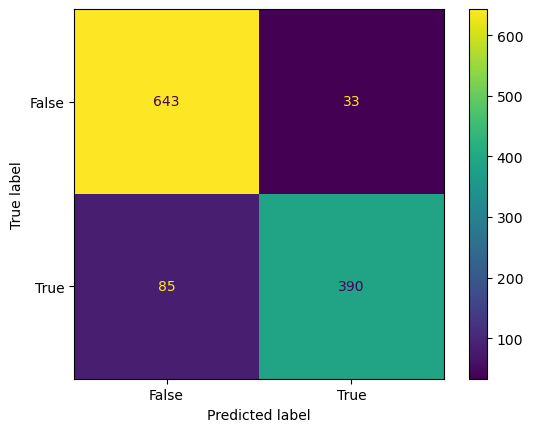

In [10]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Assuming test_predictions and test_actual are pre-defined lists or arrays
# Calculate the confusion matrix
cm = confusion_matrix(test_dependent, test_predictions, labels=list(set(test_dependent))) #Use set to get unique labels.

# Create a ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=list(set(test_dependent))) #Use set to get unique labels.

# Generate and print the classification report
print(classification_report(test_dependent, test_predictions))


# Plot the confusion matrix
disp.plot()
# Show the plot
plt.show()